In [41]:
import numpy as np
import importlib
import tg_vtss
importlib.reload(tg_vtss)
TAU_GQS = tg_vtss.TAU_GQS
GQS_FOLDS = tg_vtss.GQS_FOLDS
choose_tg_vtss_candidates = tg_vtss.choose_tg_vtss_candidates
print_tg_vtss_decision = tg_vtss.print_tg_vtss_decision
print_tg_vtss_summary = tg_vtss.print_tg_vtss_summary

from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

def make_dgp_gaussian_mixture(
    n0: int,
    n1: int,
    d: int,
    delta: float = 2.0,
    mix_sep: float = 2.5,
    minority_mix: bool = True,
    seed: int = 0,
):
    rng = np.random.default_rng(seed)
    I = np.eye(d)

    mu0 = np.zeros(d)
    X0 = rng.multivariate_normal(mu0, I, size=n0)

    e1 = np.zeros(d); e1[0] = 1.0
    mu1 = delta * e1

    if minority_mix and d >= 2:
        e2 = np.zeros(d); e2[1] = 1.0
        mu_a = mu1 + (mix_sep / 2.0) * e2
        mu_b = mu1 - (mix_sep / 2.0) * e2
        z = rng.integers(0, 2, size=n1)
        Xa = rng.multivariate_normal(mu_a, I, size=n1)
        Xb = rng.multivariate_normal(mu_b, I, size=n1)
        X1 = np.where(z[:, None] == 0, Xa, Xb)
    else:
        X1 = rng.multivariate_normal(mu1, I, size=n1)

    X = np.vstack([X0, X1]).astype(np.float64)
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    return X, y


def smote_to_target_minority(X, y, n_minority_target, seed: int = 0, k_neighbors: int = 5):
    y = y.astype(int)
    n1 = int((y == 1).sum())
    if n_minority_target <= n1:
        return X, y

    if n1 < 2:
        raise ValueError("Need at least 2 minority points for SMOTE.")
    k = min(k_neighbors, n1 - 1)

    sm = SMOTE(
        sampling_strategy={1: int(n_minority_target)},
        k_neighbors=k,
        random_state=seed,
    )
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

def fit_logreg(X, y, seed: int = 0):
    clf = LogisticRegression(
        solver="lbfgs",
        max_iter=3000,
        C=1e6,
        random_state=seed,
    )
    clf.fit(X, y)
    return clf


def balanced_logloss_and_error(clf, X, y, eps: float = 1e-12):
    p1 = clf.predict_proba(X)[:, 1]
    p1 = np.clip(p1, eps, 1 - eps)

    ll = -(y * np.log(p1) + (1 - y) * np.log(1 - p1))

    yhat = (p1 >= 0.5).astype(int)
    err = (yhat != y).astype(float)

    ll0 = ll[y == 0].mean()
    ll1 = ll[y == 1].mean()
    err0 = err[y == 0].mean()
    err1 = err[y == 1].mean()

    return 0.5 * (ll0 + ll1), 0.5 * (err0 + err1)


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit


def make_balanced_test_set_smote(
    d: int,
    n_per_class: int,
    delta: float,
    seed: int,
    minority_mix: bool = True,
    mix_sep: float = 2.5,
):
    X, y = make_dgp_gaussian_mixture(
        n0=n_per_class,
        n1=n_per_class,
        d=d,
        delta=delta,
        mix_sep=mix_sep,
        minority_mix=minority_mix,
        seed=seed,
    )
    return X, y


def run_synthsize_curve_smote(
    d=5,
    delta=2.0,
    r=20,
    n1_base=50,
    m=8,
    reps=100,
    minority_mix_train=True,
    minority_mix_eval=True, 
    mix_sep=3.5,
    validation_fraction=0.20,
    gqs_folds=GQS_FOLDS,
    n_test_per_class=10000,
    metric="logloss", 
    seed=0,
):
    rng = np.random.default_rng(seed)
    print(f"TG-VTSS base_random_seed={seed}")
    print(f"validation split: {validation_fraction:.0%} of each real training class")
    print(f"GQS cross-fitting folds K={gqs_folds}")
    print(f"test_random_seed={seed + 222}")

    n1 = int(n1_base * m)
    n0 = int(r * n1)
    gap = n0 - n1

    X_test, y_test = make_balanced_test_set_smote(
        d=d, n_per_class=n_test_per_class, delta=delta, seed=seed + 222,
        minority_mix=minority_mix_eval, mix_sep=mix_sep
    )

    curve_rows = []
    tuned_rows = []
    tg_decisions = []

    for rep in range(reps):
        print(rep)
        rep_seed = int(rng.integers(0, 2**31 - 1))

        X_real, y_real = make_dgp_gaussian_mixture(
            n0=n0, n1=n1, d=d,
            delta=delta,
            mix_sep=mix_sep,
            minority_mix=minority_mix_train,
            seed=rep_seed,
        )
        split_seed = rep_seed + 111
        splitter = StratifiedShuffleSplit(
            n_splits=1, test_size=validation_fraction, random_state=split_seed
        )
        fit_idx, val_idx = next(splitter.split(X_real, y_real))
        X_fit, y_fit = X_real[fit_idx], y_real[fit_idx]
        X_val, y_val = X_real[val_idx], y_real[val_idx]
        n0_fit = int((y_fit == 0).sum())
        n1_fit = int((y_fit == 1).sum())
        gap_fit = n0_fit - n1_fit

        def diagnostic_smote(X_real, y_real, n_synthetic, gen_seed):
            n_min = int((y_real == 1).sum())
            X_aug, _ = smote_to_target_minority(
                X_real, y_real, n_min + n_synthetic, seed=gen_seed
            )
            return X_aug[len(X_real):]

        diagnostic_estimator = LogisticRegression(
            solver="lbfgs", max_iter=3000, C=1e6, random_state=rep_seed
        )
        tg_decision = choose_tg_vtss_candidates(
            X_fit, y_fit, diagnostic_estimator, diagnostic_smote,
            tau_gqs=TAU_GQS, folds=gqs_folds, seed=rep_seed,
        )
        tg_decisions.append(tg_decision)
        print_tg_vtss_decision(rep, tg_decision, random_seed=rep_seed)
        print(
            f"  split_seed={split_seed} | fit_counts=(n0={n0_fit}, n1={n1_fit}) | "
            f"validation_counts=(n0={(y_val == 0).sum()}, n1={(y_val == 1).sum()})"
        )
        tuning_tilde_grid = list(tg_decision.candidate_sizes)
        validation_results = []
        for tilde_fit in tuning_tilde_grid:
            X_os_fit, y_os_fit = smote_to_target_minority(
                X_fit, y_fit, n_minority_target=n1_fit + tilde_fit, seed=rep_seed
            )
            clf_fit = fit_logreg(X_os_fit, y_os_fit, seed=rep_seed)
            val_ll, val_err = balanced_logloss_and_error(clf_fit, X_val, y_val)
            val_metric = val_ll if metric == "logloss" else val_err
            validation_results.append((tilde_fit, val_metric))

        tilde_fit_hat, validation_metric = min(validation_results, key=lambda t: t[1])
        gamma_hat = tilde_fit_hat / gap_fit if gap_fit > 0 else 0.0
        tilde_hat = int(round(gamma_hat * gap))

        curve_tilde_grid = sorted({
            int(round(gamma * gap)) for gamma in np.arange(0.0, 2.0001, 0.05)
        })
        full_evaluation_grid = sorted(set(curve_tilde_grid) | {tilde_hat})
        selected_test_metric = None
        for tilde in full_evaluation_grid:
            n1_target = n1 + tilde
            X_os, y_os = smote_to_target_minority(
                X_real, y_real, n_minority_target=n1_target, seed=rep_seed
            )
            clf = fit_logreg(X_os, y_os, seed=rep_seed)
            test_ll, test_err = balanced_logloss_and_error(clf, X_test, y_test)
            test_metric = test_ll if metric == "logloss" else test_err
            if tilde == tilde_hat:
                selected_test_metric = test_metric
            if tilde in curve_tilde_grid:
                curve_rows.append({
                    "rep": rep,
                    "n0": n0, "n1": n1,
                    "gap": gap,
                    "tilde": tilde,
                    "n1_target": n1_target,
                    "gamma": tilde / gap if gap > 0 else np.nan,
                    f"test_{metric}": test_metric,
                })
        tuned_rows.append({
            "rep": rep,
            "random_seed": rep_seed,
            "regime": tg_decision.regime,
            "generator_decision": tg_decision.generator_decision,
            "gqs": tg_decision.gqs,
            "n0": n0, "n1": n1,
            "gap": gap,
            "split_seed": split_seed,
            "n_fit": len(y_fit), "n_validation": len(y_val),
            "tilde_chosen_on_fit": tilde_fit_hat,
            "tilde_chosen": tilde_hat,
            "gamma_chosen": gamma_hat,
            f"validation_{metric}": validation_metric,
            f"test_{metric}": selected_test_metric,
        })

    print_tg_vtss_summary(tg_decisions)

    curve_df = pd.DataFrame(curve_rows)
    tuned_df = pd.DataFrame(tuned_rows)

    curve_sum = (curve_df
                 .groupby(["tilde", "gamma"], as_index=False)[f"test_{metric}"]
                 .agg(mean="mean", std="std", count="count")
                 .sort_values("tilde"))

    tuned_mean = tuned_df[f"test_{metric}"].mean()
    tuned_std = tuned_df[f"test_{metric}"].std()

    meta = {"n0": n0, "n1": n1, "gap": gap, "tuned_mean": tuned_mean, "tuned_std": tuned_std}
    return curve_df, tuned_df, curve_sum, meta


def plot_synthsize_curve(curve_sum: pd.DataFrame, meta: dict,
                         show_band: bool = True, band_k: float = 1.0):
    x = curve_sum["tilde"].to_numpy()
    y = curve_sum["mean"].to_numpy()
    ystd = curve_sum["std"].to_numpy()

    gap = meta["gap"]
    tuned_mean = meta["tuned_mean"]
    tuned_std = meta["tuned_std"]

    plt.figure(figsize=(7.5, 4.5))
    plt.plot(x, y, marker="o", linewidth=1.8, label=f"Test Log-Loss")

    if np.all(np.isfinite(ystd)) and np.any(ystd > 0):
        plt.fill_between(x, y - ystd, y + ystd, alpha=0.18)

    plt.axvline(gap, linestyle="--", linewidth=1.5, label=r"$\tilde n = n_0 - n_1$")

    plt.axhline(tuned_mean, linestyle="-.", linewidth=1.8,
                label=f"VTSS")

    if show_band and np.isfinite(tuned_std) and tuned_std > 0:
        plt.fill_between([x.min(), x.max()],
                         [tuned_mean - band_k * tuned_std, tuned_mean - band_k * tuned_std],
                         [tuned_mean + band_k * tuned_std, tuned_mean + band_k * tuned_std],
                         alpha=0.10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel(r"Synthetic size $\tilde n$", fontsize=12)
    plt.ylabel(f"Balanced Test Log-Loss", fontsize=12)
    plt.title(rf"Loss with SMOTE($n_0-n_1 = {gap}$)", fontsize=14)
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


TG-VTSS base_random_seed=666
validation split: 20% of each real training class
GQS cross-fitting folds K=5
test_random_seed=888
0
run=0 | random_seed=1912358658 | regime=local asymmetry | generator=realistic generator | T_sym=857.13 (cutoff=12.5916) | GQS=5.47155 (tau_GQS=10) | ||g_phi||=0.636935, ||g_psi||=0.0246354, cos=0.152379, denominator=0.988213 | theory_target=3076 | around_balance=[2432, 2584, 2736, 2888, 3040, 3192, 3344, 3496, 3648] | around_theory=[2461, 2615, 2769, 2922, 3076, 3230, 3384, 3538, 3692] | candidates=[2432, 2461, 2584, 2615, 2736, 2769, 2888, 2922, 3040, 3076, 3192, 3230, 3344, 3384, 3496, 3538, 3648, 3692]
  split_seed=1912358769 | fit_counts=(n0=3200, n1=160) | validation_counts=(n0=800, n1=40)
1
run=1 | random_seed=1641025718 | regime=local asymmetry | generator=realistic generator | T_sym=935.917 (cutoff=12.5916) | GQS=4.06955 (tau_GQS=10) | ||g_phi||=0.655301, ||g_psi||=0.0340887, cos=0.10578, denominator=0.988995 | theory_target=3074 | around_balance=[24

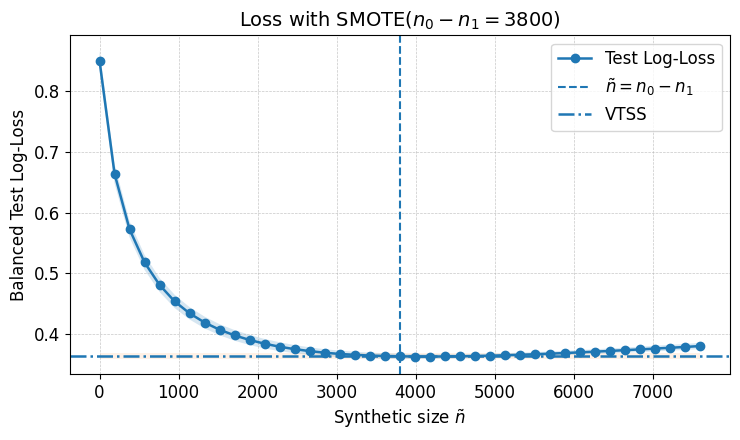

In [43]:
curve_df, tuned_df, curve_sum, meta = run_synthsize_curve_smote(
    d=5,
    delta=2.0,
    r=20,
    n1_base=50,
    m=4,                      
    reps=100,
    minority_mix_train=True,
    minority_mix_eval=True, 
    mix_sep=3.5,
    gqs_folds=5,  # K for the draft's GQS cross-fitting procedure
    metric="logloss",
    seed=666,  # Set this base seed to reproduce or change the complete experiment
)

plot_synthsize_curve(curve_sum, meta, show_band=True)

In [56]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import importlib
import tg_vtss
importlib.reload(tg_vtss)
TAU_GQS = tg_vtss.TAU_GQS
GQS_FOLDS = tg_vtss.GQS_FOLDS
choose_tg_vtss_candidates = tg_vtss.choose_tg_vtss_candidates
print_tg_vtss_decision = tg_vtss.print_tg_vtss_decision
print_tg_vtss_summary = tg_vtss.print_tg_vtss_summary

def make_dgp_complex_nongaussian(
    n0: int,
    n1: int,
    d: int,
    delta: float = 1.0,
    ring_radius: float = 2.2,
    ring_radial_sd: float = 0.12,
    ring_noise_sd: float = 0.08,
    maj_mix_prob: float = 0.30,
    maj_shift: float = 1.5, 
    maj_corr: float = 0.5,
    seed: int = 0,
):
    if d < 2:
        raise ValueError("Need d >= 2 for ring in first 2 dimensions.")
    rng = np.random.default_rng(seed)

    Sigma2 = np.array([[1.0, maj_corr], [maj_corr, 1.0]])
    L2 = np.linalg.cholesky(Sigma2)

    z = rng.random(n0) < maj_mix_prob

    mu_a = np.zeros(d)
    mu_b = np.zeros(d)
    mu_b[0] = maj_shift

    X0 = np.zeros((n0, d), dtype=float)
    eps2 = rng.normal(size=(n0, 2)) @ L2.T
    X0[:, :2] = eps2
    if d > 2:
        X0[:, 2:] = rng.normal(size=(n0, d - 2))
    X0 += mu_a
    X0[z] += (mu_b - mu_a)

    theta = rng.uniform(0, 2 * np.pi, size=n1)
    radius = ring_radius + rng.normal(0.0, ring_radial_sd, size=n1)

    X1 = np.zeros((n1, d), dtype=float)
    X1[:, 0] = delta + radius * np.cos(theta) + rng.normal(0.0, ring_noise_sd, size=n1)
    X1[:, 1] = 0.0 + radius * np.sin(theta) + rng.normal(0.0, ring_noise_sd, size=n1)
    if d > 2:
        X1[:, 2:] = rng.normal(0.0, ring_noise_sd, size=(n1, d - 2))

    X = np.vstack([X0, X1]).astype(np.float64)
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    return X, y


def make_balanced_test_set_jitter(
    d: int,
    n_per_class: int,
    delta: float,
    seed: int,
    ring_radius: float = 2.2,
    ring_radial_sd: float = 0.12,
    ring_noise_sd: float = 0.08,
    maj_mix_prob: float = 0.30,
    maj_shift: float = 1.5,
    maj_corr: float = 0.5,
):
    X, y = make_dgp_complex_nongaussian(
        n0=n_per_class,
        n1=n_per_class,
        d=d,
        delta=delta,
        ring_radius=ring_radius,
        ring_radial_sd=ring_radial_sd,
        ring_noise_sd=ring_noise_sd,
        maj_mix_prob=maj_mix_prob,
        maj_shift=maj_shift,
        maj_corr=maj_corr,
        seed=seed,
    )
    return X, y

from sklearn.kernel_approximation import RBFSampler
from sklearn.pipeline import Pipeline

def rbf_scale_gamma(X):
    return 1.0 / (X.shape[1] * max(float(np.var(X)), 1e-12))


def make_kernel_logreg(seed: int = 0, C: float = 2.0, gamma: float = 1.0, n_components: int = 500):
    return Pipeline([
        ("rbf_features", RBFSampler(
            gamma=float(gamma), n_components=n_components, random_state=seed,
        )),
        ("logreg", LogisticRegression(
            solver="lbfgs", max_iter=500, C=C, random_state=seed,
        )),
    ])


def make_warm_logreg(seed: int = 0, C: float = 2.0):
    return LogisticRegression(
        solver="lbfgs", max_iter=500, C=C,
        warm_start=True, random_state=seed,
    )


def balanced_logloss_and_error(clf, X, y, eps: float = 1e-12):
    p1 = clf.predict_proba(X)[:, 1]
    p1 = np.clip(p1, eps, 1 - eps)

    ll = -(y * np.log(p1) + (1 - y) * np.log(1 - p1))
    yhat = (p1 >= 0.5).astype(int)
    err = (yhat != y).astype(float)

    ll0 = ll[y == 0].mean()
    ll1 = ll[y == 1].mean()
    err0 = err[y == 0].mean()
    err1 = err[y == 1].mean()
    return 0.5 * (ll0 + ll1), 0.5 * (err0 + err1)

def jittered_resample_pool(
    X_minority: np.ndarray,
    tilde_max: int,
    sigma_syn: float,
    seed: int,
):
    rng = np.random.default_rng(seed)
    n1, d = X_minority.shape
    if tilde_max <= 0:
        return np.empty((0, d), dtype=float)

    idx = rng.integers(0, n1, size=tilde_max)
    X_syn = X_minority[idx] + rng.normal(0.0, sigma_syn, size=(tilde_max, d))
    return X_syn


def append_synthetics(X, y, X_syn_pool, tilde: int):
    if tilde <= 0:
        return X, y
    X_new = np.vstack([X, X_syn_pool[:tilde]])
    y_new = np.concatenate([y, np.ones(tilde, dtype=int)])
    return X_new, y_new


def run_synthsize_curve_jitter(
    d=5,
    delta=1.0,
    r=20,
    n1_base=50,
    m=8,
    reps=100,
    validation_folds=5,
    gqs_folds=GQS_FOLDS,
    n_test_per_class=10000,
    metric="logloss",
    seed=0,
    sigma_syn=0.35,
    rbf_components=500,
    diagnostic_rbf_components=100,
    curve_gamma_step=0.10,
    ring_radius=2.2,
    ring_radial_sd=0.12,
    ring_noise_sd=0.08,
    maj_mix_prob=0.30,
    maj_shift=1.5,
    maj_corr=0.5,
):
    rng = np.random.default_rng(seed)
    print(f"TG-VTSS base_random_seed={seed}")
    print(f"synthetic-size tuning: {validation_folds}-fold stratified cross-validation")
    print(f"diagnostic RBF dimension: {diagnostic_rbf_components}")
    print(f"tuning/final RBF dimension: {rbf_components}")
    print(f"GQS cross-fitting folds K={gqs_folds}")
    print(f"test_random_seed={seed + 222}")

    n1 = int(n1_base * m)
    n0 = int(r * n1)
    gap = n0 - n1

    X_test, y_test = make_balanced_test_set_jitter(
        d=d, n_per_class=n_test_per_class, delta=delta, seed=seed + 222,
        ring_radius=ring_radius, ring_radial_sd=ring_radial_sd, ring_noise_sd=ring_noise_sd,
        maj_mix_prob=maj_mix_prob, maj_shift=maj_shift, maj_corr=maj_corr
    )

    curve_rows = []
    tuned_rows = []
    tg_decisions = []

    for rep in range(reps):
        print(rep)
        rep_seed = int(rng.integers(0, 2**31 - 1))

        X_real, y_real = make_dgp_complex_nongaussian(
            n0=n0, n1=n1, d=d,
            delta=delta,
            ring_radius=ring_radius,
            ring_radial_sd=ring_radial_sd,
            ring_noise_sd=ring_noise_sd,
            maj_mix_prob=maj_mix_prob,
            maj_shift=maj_shift,
            maj_corr=maj_corr,
            seed=rep_seed,
        )
        def diagnostic_jitter(X_real, y_real, n_synthetic, gen_seed):
            return jittered_resample_pool(
                X_real[y_real == 1], n_synthetic, sigma_syn, gen_seed
            )

        diagnostic_gamma = rbf_scale_gamma(X_real)
        diagnostic_estimator = make_kernel_logreg(
            seed=rep_seed, C=2.0, gamma=diagnostic_gamma,
            n_components=diagnostic_rbf_components,
        )
        tg_decision = choose_tg_vtss_candidates(
            X_real, y_real, diagnostic_estimator, diagnostic_jitter,
            tau_gqs=TAU_GQS, folds=gqs_folds, seed=rep_seed,
        )
        tg_decisions.append(tg_decision)
        print_tg_vtss_decision(rep, tg_decision, random_seed=rep_seed)
        tuning_tilde_grid = sorted(tg_decision.candidate_sizes)
        cv_losses = {tilde: [] for tilde in tuning_tilde_grid}
        cv_seed = rep_seed + 111
        cv = StratifiedKFold(
            n_splits=validation_folds, shuffle=True, random_state=cv_seed
        )
        for fold, (fit_idx, val_idx) in enumerate(cv.split(X_real, y_real)):
            X_fit, y_fit = X_real[fit_idx], y_real[fit_idx]
            X_val, y_val = X_real[val_idx], y_real[val_idx]
            n0_fit = int((y_fit == 0).sum())
            n1_fit = int((y_fit == 1).sum())
            gap_fit = n0_fit - n1_fit
            fold_tildes = {
                tilde: int(round((tilde / gap) * gap_fit)) if gap > 0 else 0
                for tilde in tuning_tilde_grid
            }
            fold_seed = rep_seed + 10000 + fold
            fold_gamma = rbf_scale_gamma(X_fit)
            X_syn_fit_pool = jittered_resample_pool(
                X_fit[y_fit == 1],
                tilde_max=max(fold_tildes.values(), default=0),
                sigma_syn=sigma_syn, seed=fold_seed + 999,
            )
            rbf_map = RBFSampler(
                gamma=fold_gamma, n_components=rbf_components,
                random_state=fold_seed,
            )
            Z_fit = rbf_map.fit_transform(X_fit)
            Z_val = rbf_map.transform(X_val)
            Z_syn_fit_pool = rbf_map.transform(X_syn_fit_pool)
            clf_fit = make_warm_logreg(seed=fold_seed, C=2.0)
            for tilde in tuning_tilde_grid:
                tilde_fit = fold_tildes[tilde]
                Z_use_fit = np.vstack([Z_fit, Z_syn_fit_pool[:tilde_fit]])
                y_use_fit = np.concatenate([y_fit, np.ones(tilde_fit, dtype=int)])
                clf_fit.fit(Z_use_fit, y_use_fit)
                val_ll, val_err = balanced_logloss_and_error(clf_fit, Z_val, y_val)
                cv_losses[tilde].append(val_ll if metric == "logloss" else val_err)

        validation_results = [
            (tilde, float(np.mean(losses))) for tilde, losses in cv_losses.items()
        ]
        tilde_hat, validation_metric = min(validation_results, key=lambda t: t[1])
        gamma_hat = tilde_hat / gap if gap > 0 else 0.0
        print(
            f"  cv_seed={cv_seed} | validation_folds={validation_folds} | "
            f"selected_tilde={tilde_hat} | selected_gamma={gamma_hat:.6g}"
        )

        curve_tilde_grid = sorted({
            int(round(gamma * gap))
            for gamma in np.arange(0.0, 2.0 + curve_gamma_step / 2, curve_gamma_step)
        })
        full_evaluation_grid = sorted(set(curve_tilde_grid) | {tilde_hat})
        tilde_max_full = max(full_evaluation_grid) if full_evaluation_grid else 0
        X_syn_full_pool = jittered_resample_pool(
            X_real[y_real == 1], tilde_max=tilde_max_full,
            sigma_syn=sigma_syn, seed=rep_seed + 999,
        )
        full_gamma = rbf_scale_gamma(X_real)
        full_rbf_map = RBFSampler(
            gamma=full_gamma, n_components=rbf_components,
            random_state=rep_seed,
        )
        Z_real = full_rbf_map.fit_transform(X_real)
        Z_test = full_rbf_map.transform(X_test)
        Z_syn_full_pool = full_rbf_map.transform(X_syn_full_pool)
        clf = make_warm_logreg(seed=rep_seed, C=2.0)
        selected_test_metric = None
        for tilde in full_evaluation_grid:
            Z_use = np.vstack([Z_real, Z_syn_full_pool[:tilde]])
            y_use = np.concatenate([y_real, np.ones(tilde, dtype=int)])
            clf.fit(Z_use, y_use)
            test_ll, test_err = balanced_logloss_and_error(clf, Z_test, y_test)
            test_metric = test_ll if metric == "logloss" else test_err
            if tilde == tilde_hat:
                selected_test_metric = test_metric
            if tilde in curve_tilde_grid:
                curve_rows.append({
                    "rep": rep,
                    "n0": n0, "n1": n1,
                    "gap": gap,
                    "tilde": tilde,
                    "n1_target": n1 + tilde,
                    "gamma": tilde / gap if gap > 0 else np.nan,
                    f"test_{metric}": test_metric,
                })
        tuned_rows.append({
            "rep": rep,
            "random_seed": rep_seed,
            "regime": tg_decision.regime,
            "generator_decision": tg_decision.generator_decision,
            "gqs": tg_decision.gqs,
            "n0": n0, "n1": n1,
            "gap": gap,
            "cv_seed": cv_seed,
            "validation_folds": validation_folds,
            "rbf_gamma": full_gamma,
            "rbf_components": rbf_components,
            "tilde_chosen": tilde_hat,
            "gamma_chosen": gamma_hat,
            f"validation_{metric}": validation_metric,
            f"test_{metric}": selected_test_metric,
        })

    print_tg_vtss_summary(tg_decisions)

    curve_df = pd.DataFrame(curve_rows)
    tuned_df = pd.DataFrame(tuned_rows)

    curve_sum = (curve_df
                 .groupby(["tilde", "gamma"], as_index=False)[f"test_{metric}"]
                 .agg(mean="mean", std="std", count="count")
                 .sort_values("tilde"))

    tuned_mean = tuned_df[f"test_{metric}"].mean()
    tuned_std = tuned_df[f"test_{metric}"].std()

    meta = {
        "n0": n0, "n1": n1, "gap": gap,
        "tuned_mean": tuned_mean, "tuned_std": tuned_std,
        "sigma_syn": sigma_syn
    }
    return curve_df, tuned_df, curve_sum, meta


def plot_synthsize_curve(
    curve_sum: pd.DataFrame,
    meta: dict,
    show_band: bool = True,
    band_k: float = 1.0,
):
    x = curve_sum["tilde"].to_numpy()
    y = curve_sum["mean"].to_numpy()
    ystd = curve_sum["std"].to_numpy()

    gap = meta["gap"]
    tuned_mean = meta["tuned_mean"]
    tuned_std = meta["tuned_std"]

    plt.figure(figsize=(7.5, 4.5))
    plt.plot(x, y, marker="o", linewidth=1.8, label=f"Test Log-Loss")

    if np.all(np.isfinite(ystd)) and np.any(ystd > 0):
        plt.fill_between(x, y - ystd, y + ystd, alpha=0.18)

    plt.axvline(gap, linestyle="--", linewidth=1.5, label=r"$\tilde n = n_0 - n_1$")

    plt.axhline(tuned_mean, linestyle="-.", linewidth=1.8,
                label=f"VTSS")

    if show_band and np.isfinite(tuned_std) and tuned_std > 0:
        plt.fill_between([x.min(), x.max()],
                         [tuned_mean - band_k * tuned_std, tuned_mean - band_k * tuned_std],
                         [tuned_mean + band_k * tuned_std, tuned_mean + band_k * tuned_std],
                         alpha=0.10)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel(r"Synthetic size $\tilde n$", fontsize=14)
    plt.ylabel(f"Balanced Test Log-Loss", fontsize=14)
    plt.title(rf"Loss with Perturbed Sampling($n_0-n_1 = {gap}$)", fontsize=14)
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()





TG-VTSS base_random_seed=666
synthetic-size tuning: 5-fold stratified cross-validation
diagnostic RBF dimension: 100
tuning/final RBF dimension: 100
GQS cross-fitting folds K=5
test_random_seed=888
0
run=0 | random_seed=1912358658 | regime=local asymmetry | generator=biased generator | T_sym=3578.62 (cutoff=125.458) | GQS=79.2538 (tau_GQS=10) | ||g_phi||=0.076093, ||g_psi||=0.50565, cos=-0.891789, denominator=nan | theory_target=not used | around_balance=[0, 190, 380, 570, 760, 950, 1140, 1330, 1520, 1710, 1900, 2090, 2280, 2470, 2660, 2850, 3040, 3230, 3420, 3610, 3800, 3990, 4180, 4370, 4560, 4750, 4940, 5130, 5320, 5510, 5700, 5890, 6080, 6270, 6460, 6650, 6840, 7030, 7220, 7410, 7600] | around_theory=[] | candidates=[0, 190, 380, 570, 760, 950, 1140, 1330, 1520, 1710, 1900, 2090, 2280, 2470, 2660, 2850, 3040, 3230, 3420, 3610, 3800, 3990, 4180, 4370, 4560, 4750, 4940, 5130, 5320, 5510, 5700, 5890, 6080, 6270, 6460, 6650, 6840, 7030, 7220, 7410, 7600]
  cv_seed=1912358769 | validati

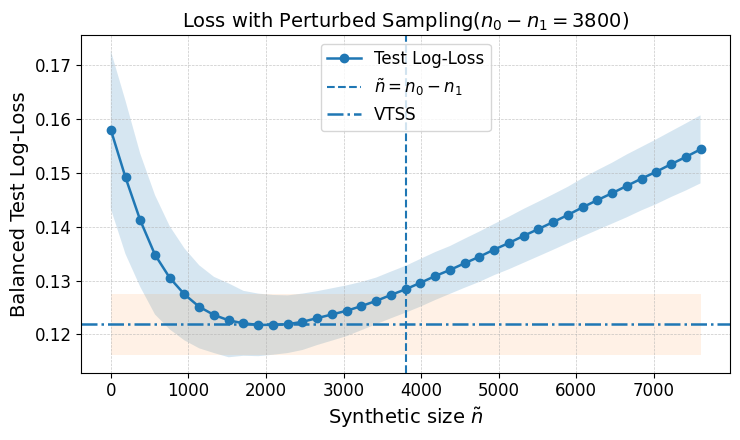

In [57]:
if __name__ == "__main__":
    curve_df, tuned_df, curve_sum, meta = run_synthsize_curve_jitter(
        d=5,
        delta=4.8,
        r=20,
        n1_base=50,
        m=4,
        reps=100,
        validation_folds=5,  # Tune synthetic size using all training samples across folds
        gqs_folds=5,  # K for the draft's GQS cross-fitting procedure
        metric="logloss",
        sigma_syn=1,
        rbf_components=100,  # Fixed random Fourier map size within each fold/run
        diagnostic_rbf_components=100,  # Previous, faster TG-VTSS diagnostic dimension
        curve_gamma_step=0.05,  # Test-curve spacing; tuning grid is unchanged
        seed=666,  # Set this base seed to reproduce or change the complete experiment
    )

    print("gap =", meta["gap"], "tuned_mean =", meta["tuned_mean"])
    plot_synthsize_curve(curve_sum, meta, show_band=True)